# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Load and Combine All CSV Files

**Instructions:** 
- Update the `data_directory` path below to point to where your CSV files are stored
- The script will automatically find all files matching the pattern `checkpoint_ebird_*.csv`

In [2]:
# UPDATE THIS PATH to where your CSV files are located
data_directory = Path('/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/20spe_2022')  # Current directory - change as needed

# Find all eBird CSV files
csv_files = list(data_directory.glob('checkpoint_ebird_*.csv'))

print(f"Found {len(csv_files)} CSV files")
print("\nFiles found:")
for i, file in enumerate(csv_files, 1):
    print(f"  {i}. {file.name}")

Found 47 CSV files

Files found:
  1. checkpoint_ebird_IT_35378_obs.csv
  2. checkpoint_ebird_UA_9461_obs.csv
  3. checkpoint_ebird_LI_37185_obs.csv
  4. checkpoint_ebird_MD_40387_obs.csv
  5. checkpoint_ebird_EE_16886_obs.csv
  6. checkpoint_ebird_RO_53262_obs.csv
  7. checkpoint_ebird_BY_3405_obs.csv
  8. checkpoint_ebird_GR_28235_obs.csv
  9. checkpoint_ebird_SI_60424_obs.csv
  10. checkpoint_ebird_VA_13010_obs.csv
  11. checkpoint_ebird_SK_58864_obs.csv
  12. checkpoint_ebird_TR_7826_obs.csv
  13. checkpoint_ebird_RU_55325_obs.csv
  14. checkpoint_ebird_CH_5357_obs.csv
  15. checkpoint_ebird_PL_48925_obs.csv
  16. checkpoint_ebird_NL_43115_obs.csv
  17. checkpoint_ebird_DK_15823_obs.csv
  18. checkpoint_ebird_PT_52100_obs.csv
  19. checkpoint_ebird_SM_55354_obs.csv
  20. checkpoint_ebird_SE_2926_obs.csv
  21. checkpoint_ebird_BA_5784_obs.csv
  22. checkpoint_ebird_XK_35604_obs.csv
  23. checkpoint_ebird_IS_30734_obs.csv
  24. checkpoint_ebird_LV_37106_obs.csv
  25. checkpoint_ebird

In [3]:
# Load and combine all CSV files
print("Loading CSV files...\n")

dfs = []
file_info = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        dfs.append(df)
        
        # Extract country code from filename (e.g., AD from checkpoint_ebird_AD_638_obs.csv)
        country_code = file.stem.split('_')[2]
        
        file_info.append({
            'File': file.name,
            'Country Code': country_code,
            'Observations': len(df)
        })
        
        print(f"✓ Loaded {file.name}: {len(df):,} observations")
    except Exception as e:
        print(f"✗ Error loading {file.name}: {e}")

# Create summary dataframe
files_df = pd.DataFrame(file_info).sort_values('Observations', ascending=False)

print(f"\n{'='*60}")
print(f"Successfully loaded {len(dfs)} files")
print(f"{'='*60}")

Loading CSV files...

✓ Loaded checkpoint_ebird_IT_35378_obs.csv: 35,378 observations
✓ Loaded checkpoint_ebird_UA_9461_obs.csv: 9,461 observations
✓ Loaded checkpoint_ebird_LI_37185_obs.csv: 37,185 observations
✓ Loaded checkpoint_ebird_MD_40387_obs.csv: 40,387 observations
✓ Loaded checkpoint_ebird_EE_16886_obs.csv: 16,886 observations
✓ Loaded checkpoint_ebird_RO_53262_obs.csv: 53,262 observations
✓ Loaded checkpoint_ebird_BY_3405_obs.csv: 3,405 observations
✓ Loaded checkpoint_ebird_GR_28235_obs.csv: 28,235 observations
✓ Loaded checkpoint_ebird_SI_60424_obs.csv: 60,424 observations
✓ Loaded checkpoint_ebird_VA_13010_obs.csv: 13,010 observations
✓ Loaded checkpoint_ebird_SK_58864_obs.csv: 58,864 observations
✓ Loaded checkpoint_ebird_TR_7826_obs.csv: 7,826 observations
✓ Loaded checkpoint_ebird_RU_55325_obs.csv: 55,325 observations
✓ Loaded checkpoint_ebird_CH_5357_obs.csv: 5,357 observations
✓ Loaded checkpoint_ebird_PL_48925_obs.csv: 48,925 observations
✓ Loaded checkpoint_ebird_

In [4]:
# Display file loading summary
print("\nFile Loading Summary:")
print(files_df.to_string(index=False))
print(f"\nTotal observations to combine: {files_df['Observations'].sum():,}")


File Loading Summary:
                             File Country Code  Observations
checkpoint_ebird_ES_64313_obs.csv           ES         64313
checkpoint_ebird_SI_60424_obs.csv           SI         60424
checkpoint_ebird_SK_58864_obs.csv           SK         58864
checkpoint_ebird_RS_56964_obs.csv           RS         56964
checkpoint_ebird_SM_55354_obs.csv           SM         55354
checkpoint_ebird_RU_55325_obs.csv           RU         55325
checkpoint_ebird_RO_53262_obs.csv           RO         53262
checkpoint_ebird_PT_52100_obs.csv           PT         52100
checkpoint_ebird_PL_48925_obs.csv           PL         48925
checkpoint_ebird_NO_46009_obs.csv           NO         46009
checkpoint_ebird_MK_43399_obs.csv           MK         43399
checkpoint_ebird_NL_43115_obs.csv           NL         43115
checkpoint_ebird_ME_40826_obs.csv           ME         40826
checkpoint_ebird_MC_40430_obs.csv           MC         40430
checkpoint_ebird_MD_40387_obs.csv           MD         40387
c

In [5]:
# Combine all dataframes
print("Combining all dataframes...")
combined_df = pd.concat(dfs, ignore_index=True)

print(f"\n✓ Combined dataset created!")
print(f"  Total observations: {len(combined_df):,}")
print(f"  Total columns: {len(combined_df.columns)}")
print(f"  Memory usage: {combined_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Combining all dataframes...

✓ Combined dataset created!
  Total observations: 1,357,159
  Total columns: 28
  Memory usage: 1469.92 MB


In [6]:
combined_df.columns.tolist()

['speciesCode',
 'comName',
 'sciName',
 'locId',
 'locName',
 'obsDt',
 'howMany',
 'lat',
 'lng',
 'obsValid',
 'obsReviewed',
 'locationPrivate',
 'subId',
 'subnational1Code',
 'subnational1Name',
 'countryCode',
 'countryName',
 'userDisplayName',
 'obsId',
 'checklistId',
 'presenceNoted',
 'hasComments',
 'hasRichMedia',
 'firstName',
 'lastName',
 'subnational2Code',
 'subnational2Name',
 'exoticCategory']

In [7]:
# Display first few rows
print("\nFirst 5 rows of combined dataset:")
combined_df.head()


First 5 rows of combined dataset:


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,subnational1Code,subnational1Name,countryCode,countryName,userDisplayName,obsId,checklistId,presenceNoted,hasComments,hasRichMedia,firstName,lastName,subnational2Code,subnational2Name,exoticCategory
0,gretit1,Great Tit,Parus major,L1066523,Schlosspark Schönbrunn,2022-01-01 15:36,1.0,48.179251,16.306372,True,False,False,S99816955,AT-9,Wien,AT,Austria,Jelmer Kuurstra,OBS1307445002,CL28980,False,False,False,Jelmer,Kuurstra,NaN,NaN,NaN
1,houspa,House Sparrow,Passer domesticus,L11318337,"55 Berchtoldshofweg, Innsbruck, Tirol, AT (47,...",2022-01-01 14:36,5.0,47.280242,11.346066,True,False,True,S99819446,AT-7,Tirol,AT,Austria,Klaus Falkensammer,OBS1307475227,CL28158,False,False,False,Klaus,Falkensammer,NaN,NaN,NaN
2,eurbul,Eurasian Bullfinch,Pyrrhula pyrrhula,L11318337,"55 Berchtoldshofweg, Innsbruck, Tirol, AT (47,...",2022-01-01 14:36,1.0,47.280242,11.346066,True,False,True,S99819446,AT-7,Tirol,AT,Austria,Klaus Falkensammer,OBS1307475218,CL28158,False,False,False,Klaus,Falkensammer,NaN,NaN,NaN
3,whtdip1,White-throated Dipper,Cinclus cinclus,L17272933,"Einsiedlinger Straße Brucke, Vorchdorf, Oberös...",2022-01-01 13:30,5.0,47.972480,13.974901,True,False,True,S99809281,AT-4,Oberösterreich,AT,Austria,Shane Sumasgutner,OBS1307369900,CL32601,False,False,False,Shane,Sumasgutner,NaN,NaN,NaN
4,gretit1,Great Tit,Parus major,L3160714,NSG Oberweiden Sandberge,2022-01-02 15:25,1.0,48.280337,16.831141,True,False,False,S99951344,AT-3,Niederösterreich,AT,Austria,Cory Kampf,OBS1308895861,CL33734,False,False,False,Cory,Kampf,NaN,NaN,NaN


In [8]:
# Check data structure
print("\nDataset Information:")
combined_df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1357159 entries, 0 to 1357158
Data columns (total 28 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   speciesCode       1357159 non-null  object 
 1   comName           1357159 non-null  object 
 2   sciName           1357159 non-null  object 
 3   locId             1357159 non-null  object 
 4   locName           1357159 non-null  object 
 5   obsDt             1357159 non-null  object 
 6   howMany           1206145 non-null  float64
 7   lat               1357159 non-null  float64
 8   lng               1357159 non-null  float64
 9   obsValid          1357159 non-null  bool   
 10  obsReviewed       1357159 non-null  bool   
 11  locationPrivate   1357159 non-null  bool   
 12  subId             1357159 non-null  object 
 13  subnational1Code  1357159 non-null  object 
 14  subnational1Name  1357159 non-null  object 
 15  countryCode       1357159 n

## 2. Data Preprocessing

In [2]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")


In [3]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,NaN,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,L5281087,P,36.001314,-5.610797,2017-01-20,S33804365,Traveling
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,S33940654,Traveling
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,S33751745,Traveling
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,S34018122,Traveling
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2017-01-21,S33908528,Traveling


In [4]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2026-01-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## 3. Basic Statistics

In [5]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 878,189
Number of countries: 46
Number of states/regions: 679
Number of counties: 1073
Number of unique species: 11
Number of locality types: 2
Number of observation types: 8

Observations with count data: 878,189 (100.0%)
Total birds counted: 15,804,317
Average count per observation: 18.00
Median count: 2
Maximum count in single observation: 140,000
Minimum count: 1


### outlier removal for col 'howMany'

In [6]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower bound: -3.5
Upper bound: 8.5

Total outliers: 122,310 (13.93% of data)

Outlier summary:
count    122310.000000
mean        115.854967
std        1757.236389
min           9.000000
25%          12.000000
50%          20.000000
75%          40.000000
max      140000.000000
Name: howMany, dtype: float64


In [7]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
10.0     15243
20.0      8804
12.0      7891
9.0       7719
15.0      7610
30.0      5636
11.0      5004
50.0      3841
25.0      3755
14.0      3725
40.0      3230
13.0      3094
16.0      2797
18.0      2435
100.0     2077
17.0      2051
60.0      1714
35.0      1599
22.0      1409
19.0      1379
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-3-50        100366
51-100        11385
101-500        8600
501-1000        885
1001-5000       816
5000+           258
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    9
  Max outlier value:    140,000
  Mean outlier value:   115.85
  Median outlier value: 20


In [8]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 10,559

Locality Type Distribution:
LOCALITY TYPE
H    8603
P    1956
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    81.48%
P    18.52%
Name: proportion, dtype: object


#### dropping outliers

In [9]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 878,189
Rows after:  867,630
Rows dropped: 10,559 (1.20% of data)


## 4. Analysis by Country

In [10]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 275724


In [11]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain              285042              11             19               48            1346258.0
          GB         United Kingdom              147178              11              4              106             696076.0
          PT               Portugal               91714              11             20              282             497542.0
          FR                 France               38844              11             13               96             184858.0
          DE                Germany               36102              11             16              343             173884.0
          PL                 Poland               28561              10             16                0             185121.0
          SE                 Sweden               25501              11             21                

## 5. Species Analysis

In [14]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
           Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
       Green Sandpiper     Tringa ochropus              359803               44           613     842970.0
                  Ruff     Calidris pugnax              109964               42           491     951843.0
            Sanderling       Calidris alba               85484               42           305     984336.0
        Wood Sandpiper     Tringa glareola               74871               42           523     418857.0
              Garganey Spatula querquedula               52675               43           511     233464.0
          Little Stint     Calidris minuta               51689               43           383     286413.0
European Honey-buzzard     Pernis apivorus               44529               42           545     208528.0
              Red Knot    Calidris canutus               39126               40           273     316233.0
      C

## 6. Temporal Analysis

In [16]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# By month
monthly_obs = combined_df.groupby('month').size().sort_index()
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
print("\nObservations by Month:")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")


TEMPORAL ANALYSIS

Observations by Year:
  2017: 61,361
  2018: 72,027
  2019: 93,957
  2020: 105,754
  2021: 149,076
  2022: 197,829
  2023: 52,807
  2024: 58,592
  2025: 71,969
  2026: 4,258

Observations by Month:
  January: 45,773
  February: 32,422
  March: 65,188
  April: 103,999
  May: 81,634
  June: 36,240
  July: 75,836
  August: 141,513
  September: 139,642
  October: 67,135
  November: 38,384
  December: 39,864

Peak observation month: August (141,513 observations)


## 7. Geographic Analysis

In [16]:
# Geographic distribution
print("\nGEOGRAPHIC DISTRIBUTION")
print("="*60)
print(f"Latitude range: {combined_df['lat'].min():.4f}° to {combined_df['lat'].max():.4f}°")
print(f"Longitude range: {combined_df['lng'].min():.4f}° to {combined_df['lng'].max():.4f}°")
print(f"\nLatitude statistics:")
print(f"  Mean: {combined_df['lat'].mean():.4f}°")
print(f"  Median: {combined_df['lat'].median():.4f}°")
print(f"\nLongitude statistics:")
print(f"  Mean: {combined_df['lng'].mean():.4f}°")
print(f"  Median: {combined_df['lng'].median():.4f}°")


GEOGRAPHIC DISTRIBUTION
Latitude range: 27.7384° to 71.2361°
Longitude range: -172.4941° to 147.4080°

Latitude statistics:
  Mean: 49.7068°
  Median: 49.8505°

Longitude statistics:
  Mean: 14.4230°
  Median: 15.0620°


## 8. Bird Species Reference Analysis

This section connects the observation data with a reference list of bird species to identify:
1. Which species from the reference list were not spotted
2. Urban vs countryside sighting patterns
3. Migration patterns by season

In [44]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


In [47]:
# Clean and prepare the reference data


# Standardize column names
bird_reference.columns = ['bird_species', 'ebird_code', 'migration_period', 'migration_group']

print(f"Total species in reference list: {len(bird_reference)}")
print(f"\nMigration groups:")
print(bird_reference['migration_group'].value_counts())
print(f"\nFirst few entries:")
print(bird_reference[['bird_species', 'ebird_code', 'migration_period', 'migration_group']].head())

Total species in reference list: 12

Migration groups:
migration_group
nocturnal              8
diurnal & nocturnal    2
diurnal                2
Name: count, dtype: int64

First few entries:
             bird_species ebird_code migration_period      migration_group
0              Black Tern     blkter                F  diurnal & nocturnal
1        Curlew Sandpiper     cursan                F            nocturnal
2  Eurasian Honey-buzzard     euhbuz                F              diurnal
3                Garganey     gargan                S            nocturnal
4         Green Sandpiper     grnsan                F            nocturnal


### 8.2 Location Type Analysis: Forest, Countryside, and City Centre

This analysis uses geographic coordinates to categorize observations into three habitat types:
- **City Centre**: Urban areas including capitals, major cities, towns, and villages
- **Countryside**: Agricultural lands, rural areas, and open habitats
- **Forest**: Woodlands, forested areas, mountain regions, and protected natural areas

**Note**: This analysis uses a combination of:
1. Location name keywords for protected areas and natural landmarks
2. Population density heuristics based on proximity to populated places
3. Elevation and geographic features to identify forested/mountainous areas

In [ ]:
# Location distribution
print("\nLOCATION ANALYSIS")
print("="*60)


each_countries = combined_df.groupby('COUNTRY').size().sort_index()

    print(f"\nCountry: {country}")
    # only instances with location data
    state_analysis_df = combined_df[combined_df['COUNTRY'].notna() & combined_df['STATE'].notna()]
    #county_analysis_df = combined_df[combined_df['COUNTRY'].notna() & combined_df['STATE'].notna() & combined_df['COUNTY'].notna() ]

    # By location
    state_analysis_obs = state_analysis_df.groupby('STATE').size().sort_index()
    #county_analysis_obs = county_analysis_df.groupby('COUNTY').size().sort_index()
    print("\nObservations by States:")
    for location, count in state_analysis_obs.items():
        print(f"  {location}: {count:,}")
    # print("\nObservations by Counties:")
    # for location, count in county_analysis_obs.items():
    #     print(f"  {location}: {count:,}")


LOCATION ANALYSIS

Country: Spain

Observations by States:
  Aargau: 1,908
  Abruzzo: 57
  AdaÅ¾i: 7
  Aizkraukle: 11
  AjdovÅ¡cina: 10
  Akershus: 1,059
  Alba: 25
  Aloja: 5
  Aluksne: 2
  Alytaus Apskritis: 76
  Ammochostos: 453
  AndalucÃ­a: 61,194
  Andrijevica: 1
  Anenii Noi: 73
  Ape: 1
  Arad: 2
  AragÃ³n: 17,829
  Arges: 13
  Asturias, Principado de: 2,890
  Attica: 4,237
  Auce: 2
  Aust-Agder: 76
  Austurland: 624
  Auvergne-RhÃ´ne-Alpes: 2,047
  Aveiro: 7,365
  Babite: 13
  Bacau: 8
  Baden-WÃ¼rttemberg: 3,764
  Balvi: 23
  Balzers: 1
  BanskobystrickÃ½ kraj: 580
  Bar: 20
  Baranya: 17
  Basel-Landschaft: 23
  Basel-Stadt: 12
  Basilicata: 30
  Bauska: 15
  Bayern: 7,569
  Beja: 5,499
  Beograd: 2,002
  Berlin: 440
  Bern: 469
  Bihor: 17
  Bitola: 4
  Bjelovarsko-bilogorska Å¾upanija: 86
  Blagoevgrad: 85
  Blekinge lÃ¤n [SE-10]: 109
  Bor: 16
  Bornholm: 388
  Borsod-AbaÃºj-ZemplÃ©n: 126
  Botosani: 2
  Bourgogne-Franche-ComtÃ©: 332
  Braga: 824
  BraganÃ§a: 601
  Brai

### 8.3 Migration Pattern Analysis by Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [56]:
# First, map migration groups to our observation data
# Create a mapping dictionary from the reference file
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_period']
))

# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)

# Classify migration groups into detailed categories
# Split Autumn Migrants into Nocturnal and Diurnal
def classify_migration(migration_group):
    if pd.isna(migration_group):
        return 'Not in Reference'
    elif migration_group == 'Resident':
        return 'Native (Resident)'
    elif migration_group == 'nocturnal':
        return 'Autumn Migrant (Nocturnal)'
    elif migration_group == 'diurnal':
        return 'Autumn Migrant (Diurnal)'
    elif migration_group == 'Spring Arrival':
        return 'Spring Migrant'
    else:
        return migration_group

combined_df['migration_category'] = combined_df['migration_group'].apply(classify_migration)

print("Migration group distribution in observations:")
print(combined_df['migration_category'].value_counts())

Migration group distribution in observations:
migration_category
F                   449841
S                   362120
Not in Reference     55669
Name: count, dtype: int64


In [57]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Autumn Migration (Late Aug to Early Dec): 316,228 observations
  Spring Migration (Mid-Mar to Mid-Jun): 246,637 observations
  Summer (Jul to Early Aug): 159,752 observations
  Winter (Late Dec to Early Mar): 145,013 observations


In [58]:
# Create cross-tabulation of migration groups vs seasons
print("="*100)
print("MIGRATION PATTERN ANALYSIS BY SEASON")
print("="*100)

# Filter to only include birds in the reference list
reference_obs = combined_df[combined_df['migration_category'] != 'Not in Reference'].copy()

migration_season_crosstab = pd.crosstab(
    reference_obs['migration_category'],
    reference_obs['season'],
    margins=True
)

print("\nObservations by Migration Group and Season:")
print("-"*100)
print(migration_season_crosstab)

# Calculate percentages
print("\n\nPercentage distribution within each migration group:")
print("-"*100)
migration_season_pct = pd.crosstab(
    reference_obs['migration_category'],
    reference_obs['season'],
    normalize='index'
) * 100
print(migration_season_pct.round(1))

MIGRATION PATTERN ANALYSIS BY SEASON

Observations by Migration Group and Season:
----------------------------------------------------------------------------------------------------
season              Autumn Migration (Late Aug to Early Dec)  Spring Migration (Mid-Mar to Mid-Jun)  Summer (Jul to Early Aug)  Winter (Late Dec to Early Mar)     All
migration_category                                                                                                                                                    
F                                                     171523                                  97755                      88455                           92108  449841
S                                                     125376                                 129957                      57514                           49273  362120
All                                                   296899                                 227712                     145969                       

In [59]:
# Detailed analysis for each migration category
print("\n" + "="*100)
print("DETAILED SEASONAL ANALYSIS BY MIGRATION GROUP")
print("="*100)

for migration_cat in ['Native (Resident)', 'Autumn Migrant (Nocturnal)', 'Autumn Migrant (Diurnal)', 'Spring Migrant']:
    print(f"\n{migration_cat.upper()}")
    print("-"*100)
    
    category_data = reference_obs[reference_obs['migration_category'] == migration_cat]
    
    if len(category_data) > 0:
        print(f"Total observations: {len(category_data):,}")
        print(f"Number of species: {category_data['speciesCode'].nunique()}")
        
        # Seasonal breakdown
        seasonal_breakdown = category_data.groupby('season').agg({
            'obsId': 'count',
            'speciesCode': 'nunique'
        }).reset_index()
        seasonal_breakdown.columns = ['Season', 'Observations', 'Species Count']
        seasonal_breakdown['Percentage'] = (seasonal_breakdown['Observations'] / len(category_data) * 100).round(1)
        
        print("\nSeasonal distribution:")
        print(seasonal_breakdown.to_string(index=False))
        
        # Top species in this category
        top_species = category_data.groupby(['comName']).size().reset_index(name='Observations')
        top_species = top_species.sort_values('Observations', ascending=False).head(5)
        print(f"\nTop 5 species in this group:")
        print(top_species.to_string(index=False))
    else:
        print(f"No observations found for {migration_cat}")


DETAILED SEASONAL ANALYSIS BY MIGRATION GROUP

NATIVE (RESIDENT)
----------------------------------------------------------------------------------------------------
No observations found for Native (Resident)

AUTUMN MIGRANT (NOCTURNAL)
----------------------------------------------------------------------------------------------------
No observations found for Autumn Migrant (Nocturnal)

AUTUMN MIGRANT (DIURNAL)
----------------------------------------------------------------------------------------------------
No observations found for Autumn Migrant (Diurnal)

SPRING MIGRANT
----------------------------------------------------------------------------------------------------
No observations found for Spring Migrant


### 8.4 Migration Pattern Visualizations

In [61]:
# Create visualizations for migration patterns
fig = plt.figure(figsize=(20, 12))

# 1. Habitat type distribution
ax1 = plt.subplot(2, 3, 1)
habitat_data = combined_df[combined_df['LOCALITY'] != 'Unknown']['LOCALITY'].value_counts()
colors_habitat = ['#3498db', '#2ecc71', '#8B4513']
ax1.pie(habitat_data.values, labels=habitat_data.index, autopct='%1.1f%%',
        colors=colors_habitat, startangle=90)
ax1.set_title('Habitat Type Distribution', fontweight='bold', fontsize=12)

# # 2. Species spotted vs unspotted
# ax2 = plt.subplot(2, 3, 2)
# spotted_data = pd.Series({
#     'Spotted': len(spotted_species),
#     'Not Spotted': len(unspotted_species)
# })
# colors_spot = ['#2ecc71', '#e74c3c']
# ax2.pie(spotted_data.values, labels=spotted_data.index, autopct='%1.1f%%',
#         colors=colors_spot, startangle=90)
# ax2.set_title('Reference Species: Spotted vs Unspotted', fontweight='bold', fontsize=12)

# 3. Migration groups distribution
ax3 = plt.subplot(2, 3, 3)
migration_dist = reference_obs['migration_category'].value_counts()
colors_mig = ['#3498db', '#e67e22', '#f39c12', '#9b59b6']
ax3.bar(range(len(migration_dist)), migration_dist.values, color=colors_mig[:len(migration_dist)], alpha=0.7)
ax3.set_xticks(range(len(migration_dist)))
ax3.set_xticklabels([label.replace('Autumn Migrant ', 'Autumn\n').replace(' (', '\n(') 
                      for label in migration_dist.index], rotation=0, ha='center', fontsize=9)
ax3.set_ylabel('Number of Observations')
ax3.set_title('Observations by Migration Category', fontweight='bold', fontsize=12)
ax3.grid(axis='y', alpha=0.3)

# 4. Seasonal observations by migration group (stacked bar)
ax4 = plt.subplot(2, 3, 4)
season_order = ['Spring Migration (Mid-Mar to Mid-Jun)', 'Summer (Jul to Early Aug)',
                'Autumn Migration (Late Aug to Early Dec)', 'Winter (Late Dec to Early Mar)']
migration_categories = ['Native (Resident)', 'Autumn Migrant (Nocturnal)', 
                       'Autumn Migrant (Diurnal)', 'Spring Migrant']

# Prepare data for stacked bar chart
season_data_dict = {cat: [] for cat in migration_categories}
for season in season_order:
    if season in reference_obs['season'].values:
        for cat in migration_categories:
            count = len(reference_obs[(reference_obs['season'] == season) & 
                                     (reference_obs['migration_category'] == cat)])
            season_data_dict[cat].append(count)
    else:
        for cat in migration_categories:
            season_data_dict[cat].append(0)

x = range(len(season_order))
width = 0.6
bottom = [0] * len(season_order)
colors_migration = ['#3498db', '#e67e22', '#f39c12', '#9b59b6']

for i, cat in enumerate(migration_categories):
    if any(season_data_dict[cat]):  # Only plot if there's data
        label = cat.replace('Autumn Migrant ', 'Autumn ').replace(' (', ' (')
        ax4.bar(x, season_data_dict[cat], width, label=label, bottom=bottom, 
                color=colors_migration[i], alpha=0.8)
        bottom = [b + v for b, v in zip(bottom, season_data_dict[cat])]

ax4.set_xticks(x)
ax4.set_xticklabels(['Spring\nMigration', 'Summer', 'Autumn\nMigration', 'Winter'], fontsize=9)
ax4.set_ylabel('Number of Observations')
ax4.set_title('Seasonal Observations by Migration Group', fontweight='bold', fontsize=12)
ax4.legend(fontsize=8, loc='upper left')
ax4.grid(axis='y', alpha=0.3)

# 5. Top species in city centres
ax5 = plt.subplot(2, 3, 5)
if 'City Centre' in combined_df['habitat_type'].values:
    city_top = combined_df[combined_df['habitat_type'] == 'City Centre'].groupby('comName').size().sort_values(ascending=False).head(10)
    ax5.barh(range(len(city_top)), city_top.values, color='steelblue', alpha=0.7)
    ax5.set_yticks(range(len(city_top)))
    labels = [name[:20] + '...' if len(name) > 20 else name for name in city_top.index]
    ax5.set_yticklabels(labels, fontsize=9)
    ax5.set_xlabel('Number of Observations')
    ax5.set_title('Top 10 Species in City Centres', fontweight='bold', fontsize=12)
    ax5.invert_yaxis()

# 6. Top species in forests
ax6 = plt.subplot(2, 3, 6)
if 'Forest' in combined_df['habitat_type'].values:
    forest_top = combined_df[combined_df['habitat_type'] == 'Forest'].groupby('comName').size().sort_values(ascending=False).head(10)
    ax6.barh(range(len(forest_top)), forest_top.values, color='forestgreen', alpha=0.7)
    ax6.set_yticks(range(len(forest_top)))
    labels = [name[:20] + '...' if len(name) > 20 else name for name in forest_top.index]
    ax6.set_yticklabels(labels, fontsize=9)
    ax6.set_xlabel('Number of Observations')
    ax6.set_title('Top 10 Species in Forests', fontweight='bold', fontsize=12)
    ax6.invert_yaxis()

plt.tight_layout()
plt.savefig('migration_habitat_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Migration and habitat analysis charts created!")

KeyError: 'habitat_type'

Error in callback <function _draw_all_if_interactive at 0x110542140> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x11456ec40> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# Heatmap of migration patterns across seasons
plt.figure(figsize=(12, 6))

# Create pivot table for heatmap
heatmap_data = reference_obs.groupby(['migration_category', 'season']).size().unstack(fill_value=0)

# Reorder columns to match season order
column_order = [col for col in season_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[column_order]

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Observations'},
            linewidths=0.5, linecolor='gray')

plt.title('Migration Pattern Heatmap: Observations by Season', fontweight='bold', fontsize=14, pad=20)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Migration Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('migration_season_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Migration season heatmap created!")

## 9. Visualizations

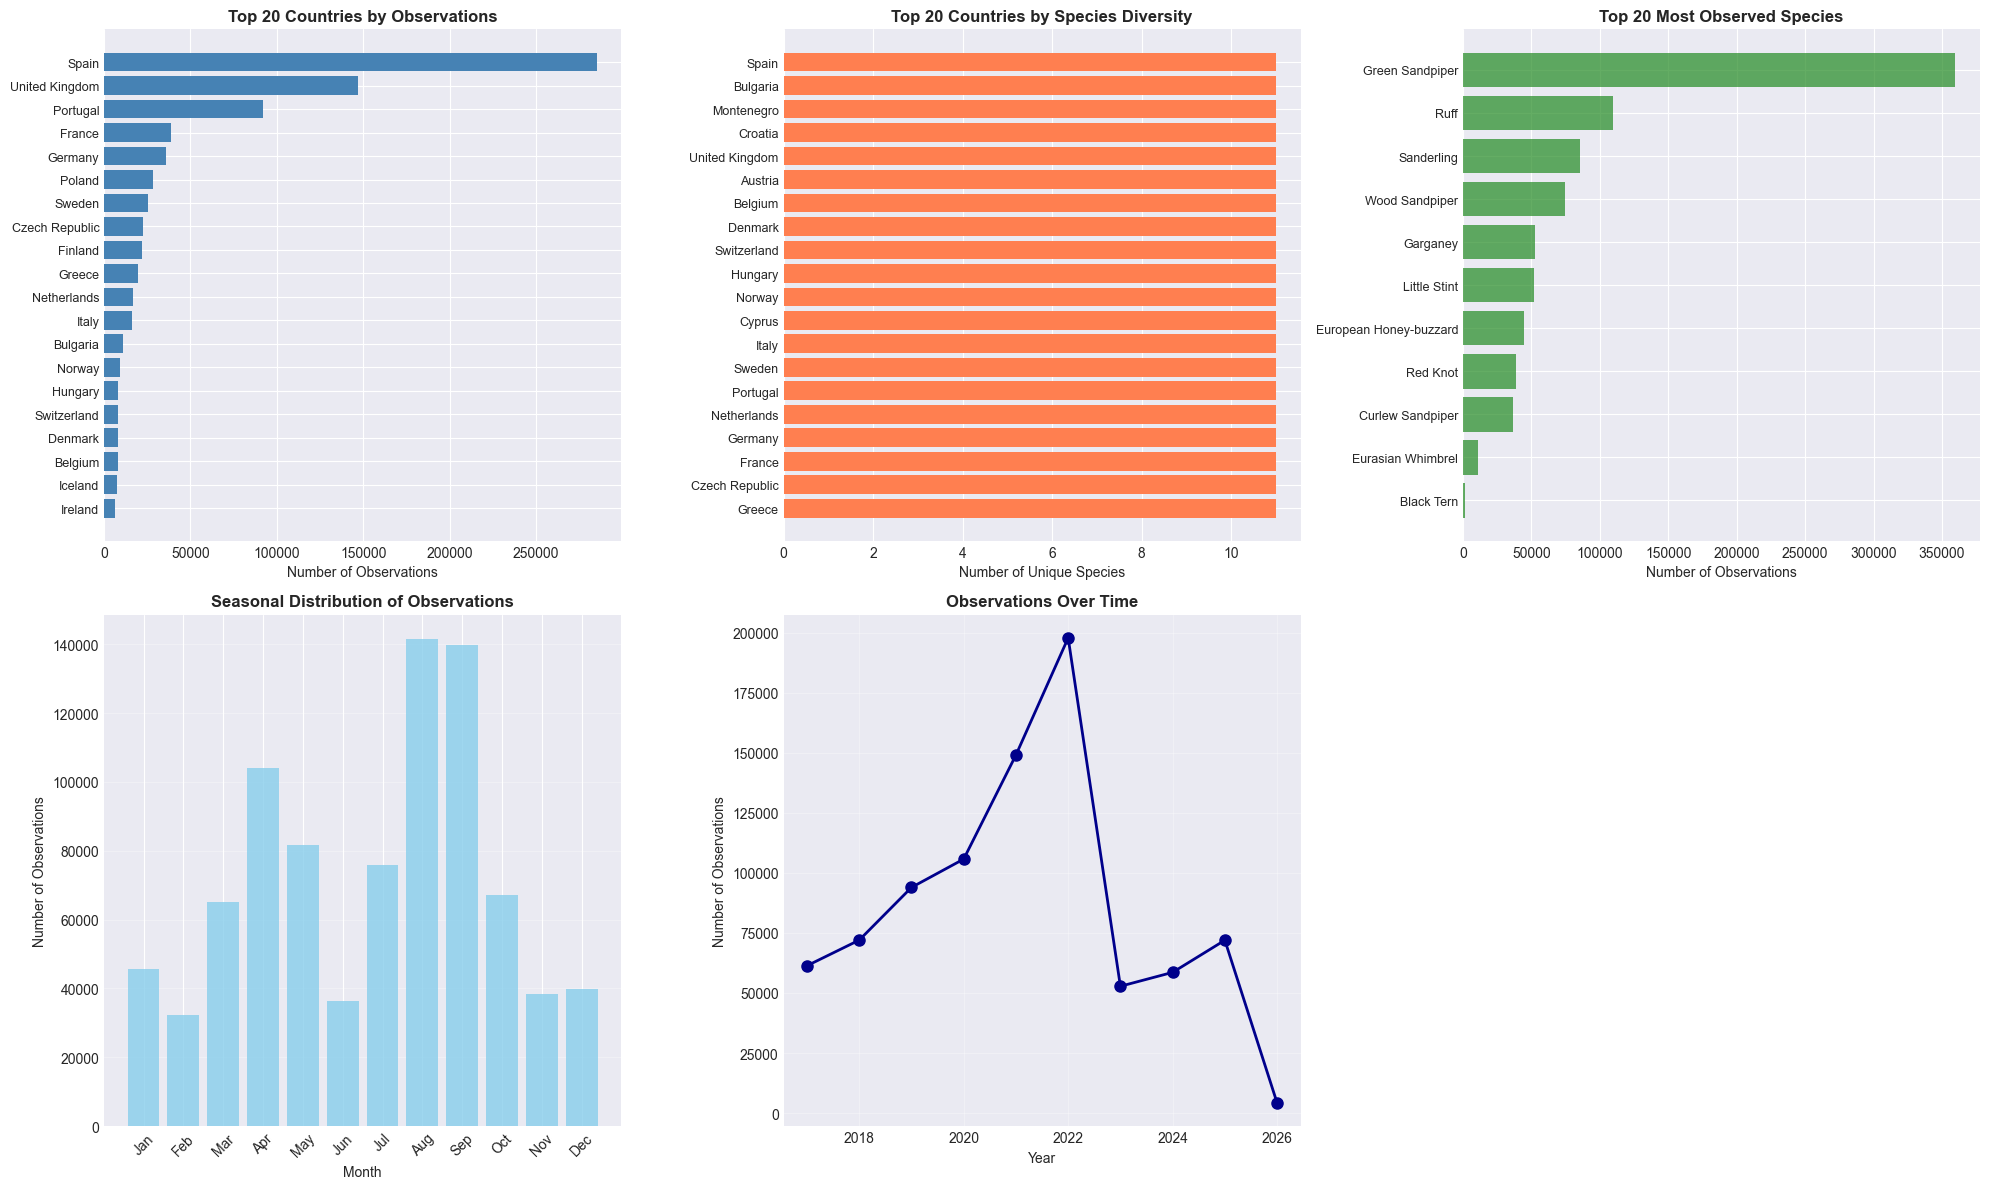

✓ Overview charts created!


In [63]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))

# 1. Top countries by observations
ax1 = plt.subplot(2, 3, 1)
top_countries = country_stats.head(20)
ax1.barh(range(len(top_countries)), top_countries['Total Observations'], color='steelblue')
ax1.set_yticks(range(len(top_countries)))
ax1.set_yticklabels(top_countries['Country Name'], fontsize=9)
ax1.set_xlabel('Number of Observations')
ax1.set_title('Top 20 Countries by Observations', fontweight='bold', fontsize=12)
ax1.invert_yaxis()

# 2. Top countries by species diversity
ax2 = plt.subplot(2, 3, 2)
top_diversity = country_stats.sort_values('Unique Species', ascending=False).head(20)
ax2.barh(range(len(top_diversity)), top_diversity['Unique Species'], color='coral')
ax2.set_yticks(range(len(top_diversity)))
ax2.set_yticklabels(top_diversity['Country Name'], fontsize=9)
ax2.set_xlabel('Number of Unique Species')
ax2.set_title('Top 20 Countries by Species Diversity', fontweight='bold', fontsize=12)
ax2.invert_yaxis()

# 3. Top species
ax3 = plt.subplot(2, 3, 3)
top_species = species_stats.head(20)
ax3.barh(range(len(top_species)), top_species['Total Observations'], color='forestgreen', alpha=0.7)
ax3.set_yticks(range(len(top_species)))
labels = [name[:25] + '...' if len(name) > 25 else name for name in top_species['Common Name']]
ax3.set_yticklabels(labels, fontsize=9)
ax3.set_xlabel('Number of Observations')
ax3.set_title('Top 20 Most Observed Species', fontweight='bold', fontsize=12)
ax3.invert_yaxis()

# 4. Observations by month
ax4 = plt.subplot(2, 3, 4)
monthly_data = combined_df[combined_df['month'].notna()].groupby('month').size()
months = list(range(1, 13))
counts = [monthly_data.get(m, 0) for m in months]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax4.bar(months, counts, color='skyblue', alpha=0.8)
ax4.set_xticks(months)
ax4.set_xticklabels(month_labels, rotation=45)
ax4.set_xlabel('Month')
ax4.set_ylabel('Number of Observations')
ax4.set_title('Seasonal Distribution of Observations', fontweight='bold', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

# 5. Observations by year
ax5 = plt.subplot(2, 3, 5)
yearly_data = combined_df[combined_df['year'].notna()].groupby('year').size().sort_index()
ax5.plot(yearly_data.index, yearly_data.values, marker='o', linewidth=2, markersize=8, color='darkblue')
ax5.set_xlabel('Year')
ax5.set_ylabel('Number of Observations')
ax5.set_title('Observations Over Time', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3)

# # 6. Species geographic distribution
# ax6 = plt.subplot(2, 3, 6)
# species_distribution = species_stats['Countries Found'].value_counts().sort_index()
# ax6.bar(species_distribution.index, species_distribution.values, color='teal', alpha=0.7)
# ax6.set_xlabel('Number of Countries')
# ax6.set_ylabel('Number of Species')
# ax6.set_title('Species Geographic Range Distribution', fontweight='bold', fontsize=12)
# ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('european_bird_analysis_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Overview charts created!")

In [ ]:
# Geographic distribution map
fig, ax = plt.subplots(figsize=(18, 12))

# Create scatter plot with country colors
scatter = ax.scatter(combined_df['lng'], combined_df['lat'], 
                    c=combined_df['countryCode'].astype('category').cat.codes,
                    alpha=0.3, s=2, cmap='tab20c')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Geographic Distribution of Bird Observations Across Europe', 
             fontweight='bold', fontsize=16, pad=20)
ax.grid(True, alpha=0.3)

# Add statistics box
stats_text = f"Total: {len(combined_df):,} observations\n" \
             f"Countries: {combined_df['countryCode'].nunique()}\n" \
             f"Species: {combined_df['speciesCode'].nunique()}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('geographic_distribution_map.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Geographic distribution map created!")

In [ ]:
# ============================================================================
# GEOGRAPHIC DISTRIBUTION MAP - COLORED BY MIGRATION GROUP
# Different colors for Native, Autumn Migrant (Nocturnal), Autumn Migrant (Diurnal), Spring Migrant
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# European country information for labeling
EUROPEAN_COUNTRIES = {
    'GB': {'name': 'United Kingdom', 'lat': 54.0, 'lon': -2.0},
    'IE': {'name': 'Ireland', 'lat': 53.0, 'lon': -8.0},
    'FR': {'name': 'France', 'lat': 47.0, 'lon': 2.0},
    'ES': {'name': 'Spain', 'lat': 40.0, 'lon': -4.0},
    'PT': {'name': 'Portugal', 'lat': 39.5, 'lon': -8.0},
    'IT': {'name': 'Italy', 'lat': 43.0, 'lon': 12.5},
    'DE': {'name': 'Germany', 'lat': 51.0, 'lon': 10.0},
    'PL': {'name': 'Poland', 'lat': 52.0, 'lon': 19.0},
    'NL': {'name': 'Netherlands', 'lat': 52.5, 'lon': 5.5},
    'BE': {'name': 'Belgium', 'lat': 50.5, 'lon': 4.5},
    'CH': {'name': 'Switzerland', 'lat': 47.0, 'lon': 8.0},
    'AT': {'name': 'Austria', 'lat': 47.5, 'lon': 14.0},
    'CZ': {'name': 'Czechia', 'lat': 49.8, 'lon': 15.5},
    'SK': {'name': 'Slovakia', 'lat': 48.7, 'lon': 19.5},
    'HU': {'name': 'Hungary', 'lat': 47.0, 'lon': 19.5},
    'RO': {'name': 'Romania', 'lat': 46.0, 'lon': 25.0},
    'BG': {'name': 'Bulgaria', 'lat': 43.0, 'lon': 25.0},
    'GR': {'name': 'Greece', 'lat': 39.0, 'lon': 22.0},
    'SE': {'name': 'Sweden', 'lat': 62.0, 'lon': 15.0},
    'NO': {'name': 'Norway', 'lat': 62.0, 'lon': 10.0},
    'FI': {'name': 'Finland', 'lat': 64.0, 'lon': 26.0},
    'DK': {'name': 'Denmark', 'lat': 56.0, 'lon': 10.0},
    'EE': {'name': 'Estonia', 'lat': 59.0, 'lon': 26.0},
    'LV': {'name': 'Latvia', 'lat': 57.0, 'lon': 25.0},
    'LT': {'name': 'Lithuania', 'lat': 55.5, 'lon': 24.0},
    'HR': {'name': 'Croatia', 'lat': 45.5, 'lon': 16.0},
    'SI': {'name': 'Slovenia', 'lat': 46.0, 'lon': 15.0},
    'BA': {'name': 'Bosnia', 'lat': 44.0, 'lon': 18.0},
    'RS': {'name': 'Serbia', 'lat': 44.0, 'lon': 21.0},
    'AL': {'name': 'Albania', 'lat': 41.0, 'lon': 20.0},
    'MK': {'name': 'N. Macedonia', 'lat': 41.6, 'lon': 21.7},
    'ME': {'name': 'Montenegro', 'lat': 42.7, 'lon': 19.3},
    'XK': {'name': 'Kosovo', 'lat': 42.6, 'lon': 20.9},
    'TR': {'name': 'Turkey', 'lat': 39.0, 'lon': 35.0},
    'CY': {'name': 'Cyprus', 'lat': 35.0, 'lon': 33.0},
    'IS': {'name': 'Iceland', 'lat': 65.0, 'lon': -18.0},
    'UA': {'name': 'Ukraine', 'lat': 49.0, 'lon': 32.0},
    'BY': {'name': 'Belarus', 'lat': 54.0, 'lon': 28.0},
    'MD': {'name': 'Moldova', 'lat': 47.0, 'lon': 29.0},
    'RU': {'name': 'Russia', 'lat': 60.0, 'lon': 40.0},
    'LU': {'name': 'Luxembourg', 'lat': 49.8, 'lon': 6.1},
    'MT': {'name': 'Malta', 'lat': 35.9, 'lon': 14.4},
    'MC': {'name': 'Monaco', 'lat': 43.7, 'lon': 7.4},
    'AD': {'name': 'Andorra', 'lat': 42.5, 'lon': 1.5},
    'LI': {'name': 'Liechtenstein', 'lat': 47.1, 'lon': 9.5},
    'SM': {'name': 'San Marino', 'lat': 43.9, 'lon': 12.5},
    'VA': {'name': 'Vatican', 'lat': 41.9, 'lon': 12.5},
}

# Coastline approximations (simplified)
COASTLINES = [
    # Atlantic/North Sea coast
    [(60, -5), (58, -3), (55, -4), (53, -6), (51, -5), (50, 1), (51, 4), (54, 5), 
     (57, 6), (59, 11), (63, 10), (65, 12), (68, 15), (70, 20), (70, 30)],
    # Mediterranean coast  
    [(36, -6), (37, -3), (38, 0), (41, 3), (43, 7), (43, 12), (40, 15), (38, 18), 
     (36, 23), (36, 28), (38, 32), (41, 28), (43, 19), (45, 14)],
    # Black Sea
    [(41, 28), (42, 29), (44, 30), (45, 31), (46, 32), (46, 38), (45, 40), 
     (43, 41), (42, 39), (41, 35), (41, 28)],
]

# Europe bounding box
lon_min, lon_max = -25, 50
lat_min, lat_max = 35, 72

# Filter data to Europe region
df_europe = combined_df[(combined_df['lng'] >= lon_min) & (combined_df['lng'] <= lon_max) & 
                        (combined_df['lat'] >= lat_min) & (combined_df['lat'] <= lat_max)]

print(f"Creating map colored by MIGRATION GROUP with {len(df_europe):,} observations...")

# Check if migration_category column exists
if 'migration_category' not in df_europe.columns:
    print("ERROR: 'migration_category' column not found in data!")
    print("Available columns:", df_europe.columns.tolist())
    print("\nThis map requires the migration_category column from your analysis.")
    print("Make sure you've run the migration analysis section first.")
else:
    # Get unique migration categories
    unique_migrations = sorted(df_europe['migration_category'].dropna().unique())
    n_migrations = len(unique_migrations)
    print(f"Found {n_migrations} migration groups: {unique_migrations}")
    
    # Define distinct colors for each migration category
    # Using meaningful colors that represent the migration behavior
    migration_colors = {
        'Native (Resident)': '#2ecc71',  # Green - stays year-round
        'Autumn Migrant (Nocturnal)': '#e67e22',  # Orange - autumn nocturnal
        'Autumn Migrant (Diurnal)': '#f39c12',  # Yellow-orange - autumn diurnal
        'Spring Migrant': '#9b59b6',  # Purple - spring migrant
    }
    
    # Use default colors for any unexpected categories
    default_color = '#95a5a6'  # Gray
    
    # Create figure with larger size
    fig, ax = plt.subplots(figsize=(26, 16), facecolor='#f0f8ff')
    ax.set_facecolor('#e6f2ff')
    
    # Draw simplified border grid
    for lon in range(-25, 50, 5):
        ax.axvline(x=lon, color='gray', alpha=0.3, linewidth=0.5, linestyle='--')
    for lat in range(35, 75, 5):
        ax.axhline(y=lat, color='gray', alpha=0.3, linewidth=0.5, linestyle='--')
    
    # Draw coastlines
    for coastline in COASTLINES:
        lats, lons = zip(*[(lat, lon) for lat, lon in coastline])
        ax.plot(lons, lats, color='steelblue', linewidth=2.5, alpha=0.7, zorder=1)
    
    # Plot observations by migration category with distinct colors
    print("Plotting observations by migration group...")
    for migration_cat in unique_migrations:
        migration_data = df_europe[df_europe['migration_category'] == migration_cat]
        if len(migration_data) > 0:
            color = migration_colors.get(migration_cat, default_color)
            ax.scatter(migration_data['lng'], migration_data['lat'], 
                      c=color, 
                      alpha=0.5, s=4, 
                      edgecolors='none',
                      zorder=2,
                      label=f"{migration_cat} ({len(migration_data):,})")
    
    # Add country code labels
    countries_in_data = df_europe['countryCode'].unique()
    for code, info in EUROPEAN_COUNTRIES.items():
        if code in countries_in_data:
            country_obs = df_europe[df_europe['countryCode'] == code]
            if len(country_obs) > 100:
                label_lon = country_obs['lng'].median()
                label_lat = country_obs['lat'].median()
                
                if lon_min <= label_lon <= lon_max and lat_min <= label_lat <= lat_max:
                    ax.text(label_lon, label_lat, code, 
                           fontsize=8, fontweight='bold', 
                           ha='center', va='center',
                           color='black',
                           bbox=dict(boxstyle='round,pad=0.4', 
                                   facecolor='white', 
                                   edgecolor='darkgray',
                                   alpha=0.75,
                                   linewidth=1.5),
                           zorder=3)
    
    # Set map extent to Europe
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    
    # Styling
    ax.set_xlabel('Longitude', fontsize=14, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=14, fontweight='bold')
    ax.set_title('Geographic Distribution of Bird Observations - Colored by Migration Group\nGreen=Native | Orange=Autumn Nocturnal | Yellow=Autumn Diurnal | Purple=Spring', 
                 fontweight='bold', fontsize=20, pad=20)
    
    # Enhanced grid
    ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='gray')
    
    # Statistics box with migration info
    total_obs = len(df_europe)
    total_countries = df_europe['countryCode'].nunique()
    total_species = df_europe['speciesCode'].nunique()
    total_locations = df_europe['locId'].nunique()
    
    # Migration group breakdown
    migration_breakdown = df_europe['migration_category'].value_counts()
    migration_text = "\n".join([f"  {cat}: {count:,} ({count/total_obs*100:.1f}%)" 
                                 for cat, count in migration_breakdown.items()])
    
    stats_text = (f"DATASET OVERVIEW\n"
                 f"{'─' * 32}\n"
                 f"Total Observations: {total_obs:,}\n"
                 f"Countries: {total_countries}\n"
                 f"Species: {total_species}\n"
                 f"Locations: {total_locations:,}\n\n"
                 f"MIGRATION GROUPS\n"
                 f"{'─' * 32}\n"
                 f"{migration_text}")
    
    ax.text(0.015, 0.985, stats_text, 
           transform=ax.transAxes, 
           fontsize=9,
           verticalalignment='top',
           bbox=dict(boxstyle='round', 
                    facecolor='wheat', 
                    alpha=0.95,
                    edgecolor='black',
                    linewidth=2),
           zorder=4,
           family='monospace')
    
    # Legend for migration categories
    legend = ax.legend(loc='lower right', 
                      framealpha=0.95, 
                      fontsize=10,
                      title='Migration Category (observations)',
                      title_fontsize=11,
                      borderpad=1,
                      labelspacing=1.0,
                      edgecolor='black',
                      facecolor='white',
                      markerscale=2)
    legend.get_frame().set_linewidth(2)
    
    # Add compass rose
    compass_x, compass_y = 0.96, 0.05
    ax.annotate('', xy=(compass_x, compass_y + 0.03), 
               xytext=(compass_x, compass_y),
               transform=ax.transAxes,
               ha='center',
               arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))
    ax.text(compass_x, compass_y + 0.035, 'N', 
           transform=ax.transAxes,
           ha='center', va='bottom',
           fontsize=14, fontweight='bold')
    
    # Add scale bar
    scale_lon = lon_min + 5
    scale_lat = lat_min + 2
    scale_length = 5  # degrees longitude
    ax.plot([scale_lon, scale_lon + scale_length], 
           [scale_lat, scale_lat], 
           'k-', linewidth=4, zorder=4, solid_capstyle='butt')
    ax.plot([scale_lon, scale_lon], 
           [scale_lat - 0.4, scale_lat + 0.4], 
           'k-', linewidth=3, zorder=4)
    ax.plot([scale_lon + scale_length, scale_lon + scale_length], 
           [scale_lat - 0.4, scale_lat + 0.4], 
           'k-', linewidth=3, zorder=4)
    ax.text(scale_lon + scale_length/2, scale_lat - 1.2, 
           '~400 km', ha='center', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                    edgecolor='black', linewidth=1))
    
    # Add color key explanation box
    color_key = (
        "COLOR KEY:\n"
        "━━━━━━━━━━━━━━━━━━\n"
        "🟢 Native (Resident)\n"
        "   Year-round residents\n\n"
        "🟠 Autumn Nocturnal\n"
        "   Migrate at night in autumn\n\n"
        "🟡 Autumn Diurnal\n"
        "   Migrate by day in autumn\n\n"
        "🟣 Spring Migrant\n"
        "   Migrate in spring"
    )
    
    ax.text(0.985, 0.52, color_key, 
           transform=ax.transAxes, 
           fontsize=9,
           verticalalignment='top',
           ha='right',
           bbox=dict(boxstyle='round', 
                    facecolor='white', 
                    alpha=0.95,
                    edgecolor='black',
                    linewidth=2),
           zorder=4,
           family='monospace')
    
    plt.tight_layout()
    plt.savefig('geographic_distribution_map_by_migration.png', dpi=300, bbox_inches='tight', 
               facecolor='#f0f8ff')
    plt.show()
    
    print("✓ Migration-colored geographic distribution map created!")
    print(f"  • {n_migrations} migration groups shown in different colors")
    print(f"  • Green = Native/Resident birds")
    print(f"  • Orange = Autumn Migrant (Nocturnal)")
    print(f"  • Yellow = Autumn Migrant (Diurnal)")
    print(f"  • Purple = Spring Migrant")
    print(f"  • Saved as: geographic_distribution_map_by_migration.png")


In [ ]:
# ============================================================================
# GEOGRAPHIC DISTRIBUTION MAP - COLORED BY SPECIES
# Each species gets a unique color to show distribution patterns
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# European country information for labeling
EUROPEAN_COUNTRIES = {
    'GB': {'name': 'United Kingdom', 'lat': 54.0, 'lon': -2.0},
    'IE': {'name': 'Ireland', 'lat': 53.0, 'lon': -8.0},
    'FR': {'name': 'France', 'lat': 47.0, 'lon': 2.0},
    'ES': {'name': 'Spain', 'lat': 40.0, 'lon': -4.0},
    'PT': {'name': 'Portugal', 'lat': 39.5, 'lon': -8.0},
    'IT': {'name': 'Italy', 'lat': 43.0, 'lon': 12.5},
    'DE': {'name': 'Germany', 'lat': 51.0, 'lon': 10.0},
    'PL': {'name': 'Poland', 'lat': 52.0, 'lon': 19.0},
    'NL': {'name': 'Netherlands', 'lat': 52.5, 'lon': 5.5},
    'BE': {'name': 'Belgium', 'lat': 50.5, 'lon': 4.5},
    'CH': {'name': 'Switzerland', 'lat': 47.0, 'lon': 8.0},
    'AT': {'name': 'Austria', 'lat': 47.5, 'lon': 14.0},
    'CZ': {'name': 'Czechia', 'lat': 49.8, 'lon': 15.5},
    'SK': {'name': 'Slovakia', 'lat': 48.7, 'lon': 19.5},
    'HU': {'name': 'Hungary', 'lat': 47.0, 'lon': 19.5},
    'RO': {'name': 'Romania', 'lat': 46.0, 'lon': 25.0},
    'BG': {'name': 'Bulgaria', 'lat': 43.0, 'lon': 25.0},
    'GR': {'name': 'Greece', 'lat': 39.0, 'lon': 22.0},
    'SE': {'name': 'Sweden', 'lat': 62.0, 'lon': 15.0},
    'NO': {'name': 'Norway', 'lat': 62.0, 'lon': 10.0},
    'FI': {'name': 'Finland', 'lat': 64.0, 'lon': 26.0},
    'DK': {'name': 'Denmark', 'lat': 56.0, 'lon': 10.0},
    'EE': {'name': 'Estonia', 'lat': 59.0, 'lon': 26.0},
    'LV': {'name': 'Latvia', 'lat': 57.0, 'lon': 25.0},
    'LT': {'name': 'Lithuania', 'lat': 55.5, 'lon': 24.0},
    'HR': {'name': 'Croatia', 'lat': 45.5, 'lon': 16.0},
    'SI': {'name': 'Slovenia', 'lat': 46.0, 'lon': 15.0},
    'BA': {'name': 'Bosnia', 'lat': 44.0, 'lon': 18.0},
    'RS': {'name': 'Serbia', 'lat': 44.0, 'lon': 21.0},
    'AL': {'name': 'Albania', 'lat': 41.0, 'lon': 20.0},
    'MK': {'name': 'N. Macedonia', 'lat': 41.6, 'lon': 21.7},
    'ME': {'name': 'Montenegro', 'lat': 42.7, 'lon': 19.3},
    'XK': {'name': 'Kosovo', 'lat': 42.6, 'lon': 20.9},
    'TR': {'name': 'Turkey', 'lat': 39.0, 'lon': 35.0},
    'CY': {'name': 'Cyprus', 'lat': 35.0, 'lon': 33.0},
    'IS': {'name': 'Iceland', 'lat': 65.0, 'lon': -18.0},
    'UA': {'name': 'Ukraine', 'lat': 49.0, 'lon': 32.0},
    'BY': {'name': 'Belarus', 'lat': 54.0, 'lon': 28.0},
    'MD': {'name': 'Moldova', 'lat': 47.0, 'lon': 29.0},
    'RU': {'name': 'Russia', 'lat': 60.0, 'lon': 40.0},
    'LU': {'name': 'Luxembourg', 'lat': 49.8, 'lon': 6.1},
    'MT': {'name': 'Malta', 'lat': 35.9, 'lon': 14.4},
    'MC': {'name': 'Monaco', 'lat': 43.7, 'lon': 7.4},
    'AD': {'name': 'Andorra', 'lat': 42.5, 'lon': 1.5},
    'LI': {'name': 'Liechtenstein', 'lat': 47.1, 'lon': 9.5},
    'SM': {'name': 'San Marino', 'lat': 43.9, 'lon': 12.5},
    'VA': {'name': 'Vatican', 'lat': 41.9, 'lon': 12.5},
}

# Coastline approximations (simplified)
COASTLINES = [
    # Atlantic/North Sea coast
    [(60, -5), (58, -3), (55, -4), (53, -6), (51, -5), (50, 1), (51, 4), (54, 5), 
     (57, 6), (59, 11), (63, 10), (65, 12), (68, 15), (70, 20), (70, 30)],
    # Mediterranean coast  
    [(36, -6), (37, -3), (38, 0), (41, 3), (43, 7), (43, 12), (40, 15), (38, 18), 
     (36, 23), (36, 28), (38, 32), (41, 28), (43, 19), (45, 14)],
    # Black Sea
    [(41, 28), (42, 29), (44, 30), (45, 31), (46, 32), (46, 38), (45, 40), 
     (43, 41), (42, 39), (41, 35), (41, 28)],
]

# Europe bounding box
lon_min, lon_max = -25, 50
lat_min, lat_max = 35, 72

# Filter data to Europe region
df_europe = combined_df[(combined_df['lng'] >= lon_min) & (combined_df['lng'] <= lon_max) & 
                        (combined_df['lat'] >= lat_min) & (combined_df['lat'] <= lat_max)]

print(f"Creating map colored by SPECIES with {len(df_europe):,} observations...")

# Get unique species and create color map
unique_species = sorted(df_europe['speciesCode'].unique())
n_species = len(unique_species)
print(f"Found {n_species} unique species")

# Create distinct colors for each species using a good colormap
# Use tab20 for up to 20 species, otherwise use hsv
if n_species <= 20:
    colors = plt.cm.tab20(np.linspace(0, 1, n_species))
else:
    colors = plt.cm.hsv(np.linspace(0, 1, n_species))
    
species_color_map = dict(zip(unique_species, colors))

# Also get common names for legend
if 'comName' in df_europe.columns:
    species_names = df_europe.groupby('speciesCode')['comName'].first().to_dict()
else:
    species_names = {code: code for code in unique_species}

# Create figure with larger size
fig, ax = plt.subplots(figsize=(26, 16), facecolor='#f0f8ff')
ax.set_facecolor('#e6f2ff')

# Draw simplified border grid
for lon in range(-25, 50, 5):
    ax.axvline(x=lon, color='gray', alpha=0.3, linewidth=0.5, linestyle='--')
for lat in range(35, 75, 5):
    ax.axhline(y=lat, color='gray', alpha=0.3, linewidth=0.5, linestyle='--')

# Draw coastlines
for coastline in COASTLINES:
    lats, lons = zip(*[(lat, lon) for lat, lon in coastline])
    ax.plot(lons, lats, color='steelblue', linewidth=2.5, alpha=0.7, zorder=1)

# Plot observations by species with distinct colors
print("Plotting observations by species...")
for i, species in enumerate(unique_species):
    species_data = df_europe[df_europe['speciesCode'] == species]
    if len(species_data) > 0:
        ax.scatter(species_data['lng'], species_data['lat'], 
                  c=[species_color_map[species]], 
                  alpha=0.5, s=4, 
                  edgecolors='none',
                  zorder=2,
                  label=f"{species_names[species]} ({len(species_data):,})")

# Add country code labels
countries_in_data = df_europe['countryCode'].unique()
for code, info in EUROPEAN_COUNTRIES.items():
    if code in countries_in_data:
        country_obs = df_europe[df_europe['countryCode'] == code]
        if len(country_obs) > 100:
            label_lon = country_obs['lng'].median()
            label_lat = country_obs['lat'].median()
            
            if lon_min <= label_lon <= lon_max and lat_min <= label_lat <= lat_max:
                ax.text(label_lon, label_lat, code, 
                       fontsize=8, fontweight='bold', 
                       ha='center', va='center',
                       color='black',
                       bbox=dict(boxstyle='round,pad=0.4', 
                               facecolor='white', 
                               edgecolor='darkgray',
                               alpha=0.75,
                               linewidth=1.5),
                       zorder=3)

# Set map extent to Europe
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# Styling
ax.set_xlabel('Longitude', fontsize=14, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=14, fontweight='bold')
ax.set_title('Geographic Distribution of Bird Observations - Colored by Species\nEach color represents a different bird species', 
             fontweight='bold', fontsize=20, pad=20)

# Enhanced grid
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='gray')

# Statistics box with species info
total_obs = len(df_europe)
total_countries = df_europe['countryCode'].nunique()
total_species = df_europe['speciesCode'].nunique()
total_locations = df_europe['locId'].nunique()

# Top 5 species by observation count
top_species = df_europe['speciesCode'].value_counts().head(5)
top_species_text = "\n".join([f"  {species_names.get(code, code)[:20]}: {count:,}" 
                               for code, count in top_species.items()])

stats_text = (f"DATASET OVERVIEW\n"
             f"{'─' * 30}\n"
             f"Total Observations: {total_obs:,}\n"
             f"Countries: {total_countries}\n"
             f"Species: {total_species}\n"
             f"Locations: {total_locations:,}\n\n"
             f"TOP 5 SPECIES\n"
             f"{'─' * 30}\n"
             f"{top_species_text}")

ax.text(0.015, 0.985, stats_text, 
       transform=ax.transAxes, 
       fontsize=10,
       verticalalignment='top',
       bbox=dict(boxstyle='round', 
                facecolor='wheat', 
                alpha=0.95,
                edgecolor='black',
                linewidth=2),
       zorder=4,
       family='monospace')

# Legend for species (show all if <= 20, otherwise show top 10)
if n_species <= 20:
    legend = ax.legend(loc='lower right', 
                      framealpha=0.95, 
                      fontsize=8,
                      title='Species (observations)',
                      title_fontsize=9,
                      ncol=2,
                      borderpad=1,
                      labelspacing=0.6,
                      columnspacing=1.5,
                      edgecolor='black',
                      facecolor='white')
    legend.get_frame().set_linewidth(2)
else:
    # Show top 10 species in legend
    print(f"Too many species ({n_species}) for full legend - showing top 10")
    # Clear previous legend items and add top 10
    handles, labels = ax.get_legend_handles_labels()
    # Sort by observation count (already in order from plotting)
    top_10_indices = [i for i in range(min(10, len(handles)))]
    legend = ax.legend([handles[i] for i in top_10_indices],
                      [labels[i] for i in top_10_indices],
                      loc='lower right', 
                      framealpha=0.95, 
                      fontsize=8,
                      title=f'Top 10 Species (of {n_species})',
                      title_fontsize=9,
                      ncol=2,
                      borderpad=1,
                      labelspacing=0.6,
                      columnspacing=1.5,
                      edgecolor='black',
                      facecolor='white')
    legend.get_frame().set_linewidth(2)

# Add compass rose
compass_x, compass_y = 0.96, 0.05
ax.annotate('', xy=(compass_x, compass_y + 0.03), 
           xytext=(compass_x, compass_y),
           transform=ax.transAxes,
           ha='center',
           arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))
ax.text(compass_x, compass_y + 0.035, 'N', 
       transform=ax.transAxes,
       ha='center', va='bottom',
       fontsize=14, fontweight='bold')

# Add scale bar
scale_lon = lon_min + 5
scale_lat = lat_min + 2
scale_length = 5  # degrees longitude
ax.plot([scale_lon, scale_lon + scale_length], 
       [scale_lat, scale_lat], 
       'k-', linewidth=4, zorder=4, solid_capstyle='butt')
ax.plot([scale_lon, scale_lon], 
       [scale_lat - 0.4, scale_lat + 0.4], 
       'k-', linewidth=3, zorder=4)
ax.plot([scale_lon + scale_length, scale_lon + scale_length], 
       [scale_lat - 0.4, scale_lat + 0.4], 
       'k-', linewidth=3, zorder=4)
ax.text(scale_lon + scale_length/2, scale_lat - 1.2, 
       '~400 km', ha='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                edgecolor='black', linewidth=1))

plt.tight_layout()
plt.savefig('geographic_distribution_map_by_species.png', dpi=300, bbox_inches='tight', 
           facecolor='#f0f8ff')
plt.show()

print("✓ Species-colored geographic distribution map created!")
print(f"  • {n_species} species shown in different colors")
print(f"  • Each dot color represents a different bird species")
print(f"  • Saved as: geographic_distribution_map_by_species.png")


In [ ]:
# ============================================================================
# ULTRA-DETAILED GEOGRAPHIC DISTRIBUTION MAP
# Advanced version with precise country boundaries and enhanced visualization
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Simplified country boundary polygons (key European countries)
# Format: country_code: [(lon, lat), ...]
COUNTRY_BOUNDARIES = {
    'GB': [(-6, 58), (-3, 59), (0, 58), (2, 52), (1, 50), (-2, 50), (-5, 52), (-6, 55), (-6, 58)],
    'FR': [(-5, 48), (-2, 51), (3, 51), (8, 49), (8, 47), (7, 44), (4, 43), (2, 42), (-2, 43), (-2, 48), (-5, 48)],
    'ES': [(-9, 43), (-7, 42), (-2, 43), (2, 42), (3, 40), (0, 38), (-2, 37), (-7, 37), (-9, 40), (-9, 43)],
    'IT': [(8, 47), (13, 47), (16, 41), (18, 40), (16, 38), (15, 37), (12, 37), (10, 43), (8, 44), (8, 47)],
    'DE': [(6, 54), (10, 55), (14, 53), (15, 51), (13, 48), (10, 47), (7, 48), (6, 50), (6, 54)],
    'PL': [(14, 54), (17, 55), (23, 54), (24, 50), (23, 49), (18, 49), (15, 50), (14, 54)],
    'SE': [(11, 56), (13, 58), (18, 59), (22, 66), (24, 68), (20, 69), (16, 68), (12, 63), (11, 56)],
    'NO': [(5, 59), (8, 61), (12, 63), (16, 68), (24, 70), (28, 71), (25, 69), (20, 69), (11, 61), (5, 59)],
}

# Major city locations for reference
MAJOR_CITIES = {
    'London': (51.5, -0.1),
    'Paris': (48.9, 2.4),
    'Berlin': (52.5, 13.4),
    'Madrid': (40.4, -3.7),
    'Rome': (41.9, 12.5),
    'Warsaw': (52.2, 21.0),
    'Stockholm': (59.3, 18.1),
    'Oslo': (59.9, 10.8),
    'Helsinki': (60.2, 25.0),
    'Vienna': (48.2, 16.4),
    'Prague': (50.1, 14.4),
    'Budapest': (47.5, 19.1),
    'Athens': (38.0, 23.7),
    'Bucharest': (44.4, 26.1),
    'Kiev': (50.5, 30.5),
    'Lisbon': (38.7, -9.1),
    'Dublin': (53.3, -6.3),
    'Copenhagen': (55.7, 12.6),
    'Amsterdam': (52.4, 4.9),
    'Brussels': (50.8, 4.4),
}

# Regional seas
SEAS = {
    'North Sea': (55, 4),
    'Baltic Sea': (58, 20),
    'Mediterranean': (38, 18),
    'Black Sea': (44, 35),
    'Atlantic Ocean': (45, -15),
}

# Europe bounding box (fills screen)
lon_min, lon_max = -25, 50
lat_min, lat_max = 35, 72

# Filter data to Europe
df_europe = combined_df[(combined_df['lng'] >= lon_min) & (combined_df['lng'] <= lon_max) & 
                        (combined_df['lat'] >= lat_min) & (combined_df['lat'] <= lat_max)]

print(f"Creating ultra-detailed map with {len(df_europe):,} observations...")

# Create figure
fig = plt.figure(figsize=(28, 18), facecolor='#e8f4f8')
ax = fig.add_subplot(111, facecolor='#d6ecf5')

# Draw refined grid (latitude/longitude lines)
for lon in np.arange(-20, 50, 5):
    ax.axvline(x=lon, color='lightgray', alpha=0.4, linewidth=0.7, linestyle=':')
    if lon % 10 == 0:
        ax.axvline(x=lon, color='gray', alpha=0.5, linewidth=1.0, linestyle='--')
        
for lat in np.arange(35, 75, 5):
    ax.axhline(y=lat, color='lightgray', alpha=0.4, linewidth=0.7, linestyle=':')
    if lat % 10 == 0:
        ax.axhline(y=lat, color='gray', alpha=0.5, linewidth=1.0, linestyle='--')

# Draw country boundaries
print("Drawing country boundaries...")
for country_code, boundary in COUNTRY_BOUNDARIES.items():
    lons, lats = zip(*[(lon, lat) for lat, lon in boundary])
    ax.plot(lons, lats, color='#2c3e50', linewidth=2.5, alpha=0.8, zorder=2)
    ax.fill(lons, lats, color='white', alpha=0.15, zorder=1)

# Color mapping for countries
countries_in_data = sorted(df_europe['countryCode'].unique())
n_countries = len(countries_in_data)

# Use multiple colormaps for variety
colors = []
for i, country in enumerate(countries_in_data):
    hue = i / n_countries
    colors.append(plt.cm.hsv(hue))
color_map = dict(zip(countries_in_data, colors))

# Plot observations with distinct colors per country
print("Plotting observations...")
for i, country in enumerate(countries_in_data):
    country_data = df_europe[df_europe['countryCode'] == country]
    if len(country_data) > 0:
        ax.scatter(country_data['lng'], country_data['lat'], 
                  c=[color_map[country]], 
                  alpha=0.35, s=2.5, 
                  edgecolors='none',
                  zorder=3,
                  label=country if i < 25 else None)

# Add country labels at observation centers
print("Adding country labels...")
for code in countries_in_data:
    country_obs = df_europe[df_europe['countryCode'] == code]
    if len(country_obs) > 50:  # Only label countries with sufficient data
        label_lon = country_obs['lng'].median()
        label_lat = country_obs['lat'].median()
        
        if lon_min <= label_lon <= lon_max and lat_min <= label_lat <= lat_max:
            # Calculate observation density for this country
            obs_count = len(country_obs)
            
            # Adjust label styling based on observation count
            fontsize = min(12, max(7, 7 + np.log10(obs_count)))
            
            ax.text(label_lon, label_lat, code, 
                   fontsize=fontsize, fontweight='bold', 
                   ha='center', va='center',
                   color='#2c3e50',
                   bbox=dict(boxstyle='round,pad=0.5', 
                           facecolor='white', 
                           edgecolor='#34495e',
                           alpha=0.9,
                           linewidth=2),
                   zorder=5)

# Add major city markers
print("Adding major cities...")
for city, (lat, lon) in MAJOR_CITIES.items():
    if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
        ax.plot(lon, lat, 'k*', markersize=8, zorder=4, 
               markeredgecolor='white', markeredgewidth=1)
        ax.text(lon + 0.8, lat + 0.5, city, fontsize=7, 
               style='italic', alpha=0.7, zorder=4)

# Add sea labels
for sea, (lat, lon) in SEAS.items():
    if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
        ax.text(lon, lat, sea, fontsize=10, 
               ha='center', va='center',
               color='#2980b9', alpha=0.6,
               style='italic', fontweight='bold')

# Set extent
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# Enhanced styling
ax.set_xlabel('Longitude (°E)', fontsize=16, fontweight='bold')
ax.set_ylabel('Latitude (°N)', fontsize=16, fontweight='bold')
ax.set_title('Geographic Distribution of Bird Observations Across Europe\nDetailed Country Boundaries and Observation Density', 
             fontweight='bold', fontsize=22, pad=25)

# Major grid with labels
ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8, color='gray')

# Detailed statistics panel
total_obs = len(df_europe)
total_countries = df_europe['countryCode'].nunique()
total_species = df_europe['speciesCode'].nunique()
total_locations = df_europe['locId'].nunique()

# Top 5 countries
top_countries = df_europe['countryCode'].value_counts().head(5)
top_countries_text = "\n".join([f"  {code}: {count:,}" for code, count in top_countries.items()])

stats_text = (
    f"DATASET OVERVIEW\n"
    f"{'─' * 30}\n"
    f"Total Observations: {total_obs:,}\n"
    f"Countries: {total_countries}\n"
    f"Species: {total_species:,}\n"
    f"Locations: {total_locations:,}\n\n"
    f"COVERAGE\n"
    f"{'─' * 30}\n"
    f"Latitude: {lat_min}° to {lat_max}°\n"
    f"Longitude: {lon_min}° to {lon_max}°\n\n"
    f"TOP 5 COUNTRIES\n"
    f"{'─' * 30}\n"
    f"{top_countries_text}"
)

ax.text(0.015, 0.985, stats_text, 
       transform=ax.transAxes, 
       fontsize=10,
       verticalalignment='top',
       bbox=dict(boxstyle='round,pad=1', 
                facecolor='#ecf0f1', 
                alpha=0.95,
                edgecolor='#2c3e50',
                linewidth=3),
       zorder=6,
       family='monospace',
       linespacing=1.5)

# Legend for top countries (if not too many)
if len(countries_in_data) <= 25:
    legend = ax.legend(loc='upper right', 
                      framealpha=0.95, 
                      fontsize=8,
                      title='Country Codes',
                      title_fontsize=10,
                      ncol=3,
                      borderpad=1,
                      labelspacing=0.8,
                      columnspacing=1.5,
                      edgecolor='#2c3e50',
                      facecolor='#ecf0f1')
    legend.get_frame().set_linewidth(2)

# Enhanced compass rose
compass_x, compass_y = 0.97, 0.04
# North arrow
ax.annotate('', xy=(compass_x, compass_y + 0.035), 
           xytext=(compass_x, compass_y),
           transform=ax.transAxes,
           arrowprops=dict(arrowstyle='->', lw=3, color='#2c3e50'))
ax.text(compass_x, compass_y + 0.04, 'N', 
       transform=ax.transAxes,
       ha='center', va='bottom',
       fontsize=16, fontweight='bold', color='#2c3e50')

# Cardinal directions
cardinal_size = 0.015
for direction, (dx, dy) in [('E', (cardinal_size, 0)), ('W', (-cardinal_size, 0)), ('S', (0, -cardinal_size))]:
    ax.text(compass_x + dx, compass_y + dy, direction,
           transform=ax.transAxes,
           ha='center', va='center',
           fontsize=11, color='#2c3e50', alpha=0.7)

# Enhanced scale bar with multiple distances
scale_lon = lon_min + 4
scale_lat = lat_min + 1.5
scale_lengths = [5, 10]  # Multiple scale bars
scale_colors = ['black', 'darkgray']

for i, (length, color) in enumerate(zip(scale_lengths, scale_colors)):
    y_offset = i * 0.8
    ax.plot([scale_lon, scale_lon + length], 
           [scale_lat - y_offset, scale_lat - y_offset], 
           color=color, linewidth=5, zorder=4, solid_capstyle='butt')
    ax.plot([scale_lon, scale_lon], 
           [scale_lat - 0.5 - y_offset, scale_lat + 0.5 - y_offset], 
           color=color, linewidth=3, zorder=4)
    ax.plot([scale_lon + length, scale_lon + length], 
           [scale_lat - 0.5 - y_offset, scale_lat + 0.5 - y_offset], 
           color=color, linewidth=3, zorder=4)
    
    # Distance label (approximate)
    km_approx = int(length * 80)  # ~80km per degree at European latitudes
    ax.text(scale_lon + length/2, scale_lat - 1.5 - y_offset, 
           f'~{km_approx} km', 
           ha='center', fontsize=9, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.95, 
                    edgecolor=color, linewidth=1.5))

# Add data attribution
ax.text(0.5, 0.005, 
       'Data Source: eBird | 47 European Countries | 2022', 
       transform=ax.transAxes,
       ha='center', va='bottom',
       fontsize=9, style='italic', alpha=0.7)

plt.tight_layout()
plt.savefig('geographic_distribution_map_ultra_detailed.png', 
           dpi=350, bbox_inches='tight', facecolor='#e8f4f8')
plt.show()

print("✓ Ultra-detailed geographic distribution map created!")
print("\nFeatures:")
print("  ✓ Europe fills entire screen (35°N - 72°N, 25°W - 50°E)")
print("  ✓ Country boundaries with shading")
print("  ✓ Country code labels at observation centers")
print("  ✓ Major cities marked with stars")
print("  ✓ Sea and ocean labels")
print("  ✓ Enhanced grid with major/minor lines")
print("  ✓ Compass rose with cardinal directions")
print("  ✓ Multiple distance scale bars")
print("  ✓ Comprehensive statistics panel")
print("  ✓ Top 5 countries by observations")
print("  ✓ Color-coded observations by country")
print(f"  ✓ High resolution (350 DPI) output")


## 10. Statistical Tests and Correlations

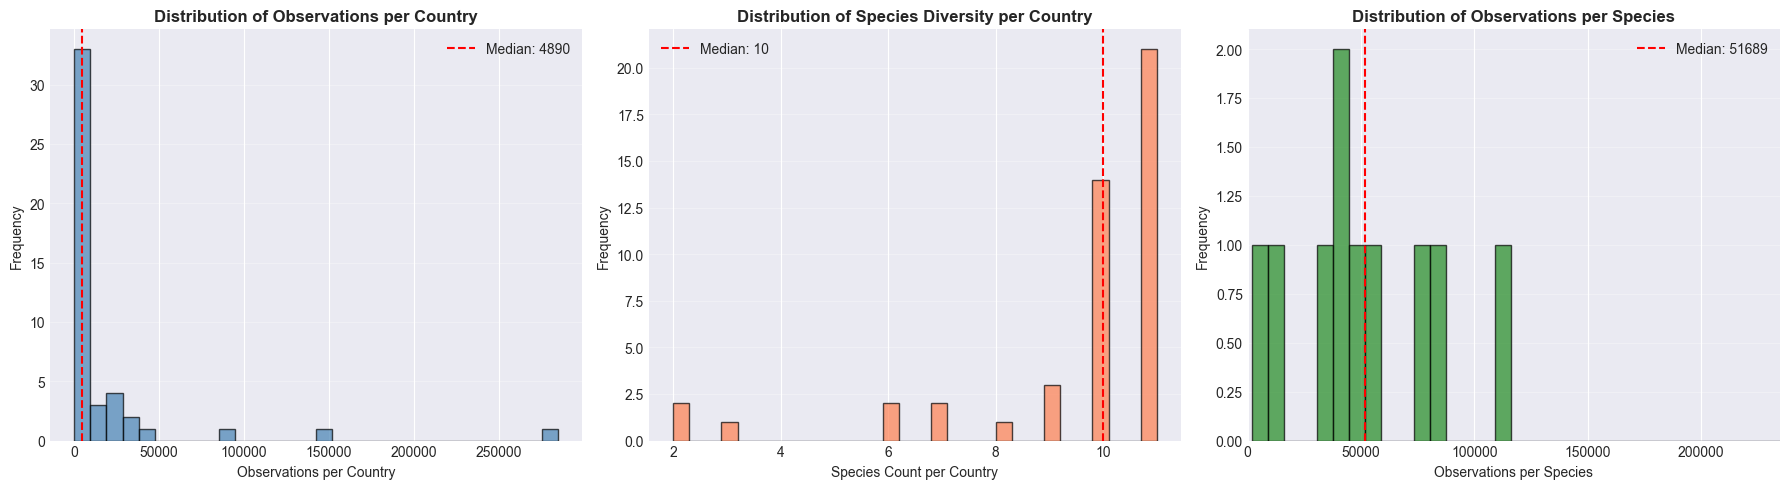

✓ Distribution analysis complete!


In [67]:
# Distribution analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of observations per country
axes[0].hist(country_stats['Total Observations'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Observations per Country')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Observations per Country', fontweight='bold')
axes[0].axvline(country_stats['Total Observations'].median(), color='red', 
                   linestyle='--', label=f'Median: {country_stats["Total Observations"].median():.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Distribution of species per country
axes[1].hist(country_stats['Unique Species'], bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Species Count per Country')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Species Diversity per Country', fontweight='bold')
axes[1].axvline(country_stats['Unique Species'].median(), color='red', 
                   linestyle='--', label=f'Median: {country_stats["Unique Species"].median():.0f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# 3. Distribution of observations per species
axes[2].hist(species_stats['Total Observations'], bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Observations per Species')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Observations per Species', fontweight='bold')
axes[2].set_xlim(0, species_stats['Total Observations'].quantile(0.95))
axes[2].axvline(species_stats['Total Observations'].median(), color='red', 
                   linestyle='--', label=f'Median: {species_stats["Total Observations"].median():.0f}')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution analysis complete!")